# Evaluación procesual - Hito 1  
## Proyecto EduAnalytics: Análisis de patrones de uso de IA generativa y riesgo de burnout estudiantil

**Materia:** Minería de Datos  
**Universidad:** Universidad Privada Franz Tamayo - UNIFRANZ  

**Integrantes:**  
- Milenka Melody Chuquimia Osco  
- Edson Teddy Tito Chuquimia  
- Carlos Daniel Valverde Mendoza  
- Alvaro Luis Carlos del Carpio Blanco  
- Marcelo Josue Escobar Chipana

Este notebook demuestra con código los resultados usados en la presentación oral. Se trabaja sobre las fases evaluadas de CRISP-DM: **Entendimiento del negocio** y **Entendimiento de los datos mediante EDA**.

## 1. Objetivo de negocio

Identificar patrones de uso de IA generativa y hábitos académicos asociados con niveles elevados de riesgo de burnout, para apoyar la detección de perfiles de mayor riesgo y futuras estrategias de uso responsable de IA en estudiantes.

**Decisión que se busca apoyar:** reconocer perfiles estudiantiles con mayor riesgo y orientar acciones preventivas o pedagógicas, sin usar el modelo como diagnóstico clínico ni como mecanismo de sanción automática.

## 2. Métrica principal / KPI

**KPI seleccionado:** porcentaje de estudiantes clasificados con riesgo alto de burnout.

**Variable utilizada:** `Burnout_Risk_Level`  
**Unidad:** porcentaje (%)  
**Fórmula:**

$KPI = rac{N°\ de\ estudiantes\ con\ Burnout\ Risk\ Level = High}{N°\ total\ de\ estudiantes} 	imes 100$

**Nota metodológica:** se trabaja con **riesgo de burnout**, no con diagnóstico clínico de burnout.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

In [2]:
# Carga del dataset
from pathlib import Path

possible_paths = [
    Path('data/raw/ai_student_impact_dataset.csv'),
    Path('data/raw/ai_student_impact_dataset (1).csv'),
    Path('/mnt/data/ai_student_impact_dataset (1).csv')
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError('No se encontró el dataset. Colócalo en data/raw/ai_student_impact_dataset.csv')

print(f'Dataset cargado desde: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
df.head()

Dataset cargado desde: /mnt/data/ai_student_impact_dataset (1).csv


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.310,Copywriting/Drafting,Beginner,1,True,8.130,5,Allowed_With_Citation,6,2.393,86.440,High
1,100002,Medical,Junior,3.821,1.120,Ideation,Advanced,5,False,16.650,3,Allowed_With_Citation,9,3.696,69.390,Low
2,100003,Business,Freshman,3.398,21.260,Summarizing_Reading,Beginner,2,False,10.350,5,Strict_Ban,9,3.499,73.930,Medium
3,100004,Business,Senior,3.789,1.820,Copywriting/Drafting,Intermediate,4,False,15.230,2,Allowed_With_Citation,2,4.000,63.580,Medium
4,100005,STEM,Sophomore,3.635,9.290,Debugging/Troubleshooting,Advanced,4,False,12.550,4,Allowed_With_Citation,4,3.798,100.000,Medium


## 3. Descripción de la fuente y unidad de análisis

**Fuente:** Kaggle  
**Archivo:** `ai_student_impact_dataset (1).csv`  
**Unidad de análisis:** un estudiante por fila.

Cada registro contiene información académica, hábitos de uso de IA generativa, nivel de dependencia percibida, ansiedad en exámenes, retención de habilidades y nivel de riesgo de burnout.

In [3]:
# Anatomía y estructura básica
print('Dimensiones del dataset:', df.shape)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])
print('\nTipos de datos:')
df.dtypes

Dimensiones del dataset: (50000, 16)
Filas: 50000
Columnas: 16

Tipos de datos:


Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object

In [4]:
# Uso de memoria
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Uso de memoria: {memory_mb:.2f} MB')

Uso de memoria: 20.60 MB


## 4. Diccionario básico de variables

La siguiente tabla traduce las columnas al español y define su rol dentro del proyecto.

In [5]:
column_dictionary = pd.DataFrame({
    'Columna original': [
        'Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
        'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
        'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
        'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams',
        'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level'
    ],
    'Traducción / significado': [
        'Identificador del estudiante', 'Área académica', 'Año o nivel de estudios',
        'GPA antes del semestre', 'Horas semanales de uso de IA generativa',
        'Principal finalidad de uso de IA', 'Habilidad para formular prompts',
        'Diversidad de herramientas de IA utilizadas', 'Suscripción pagada de IA',
        'Horas de estudio tradicional por semana', 'Dependencia percibida de IA',
        'Política institucional sobre IA', 'Ansiedad durante exámenes',
        'GPA después del semestre', 'Retención de habilidades',
        'Nivel de riesgo de burnout'
    ],
    'Rol': [
        'ID / trazabilidad', 'Contexto', 'Contexto', 'Predictora académica',
        'Predictora clave', 'Predictora clave', 'Predictora contextual',
        'Predictora contextual', 'Predictora secundaria', 'Predictora clave',
        'Predictora clave / posible objetivo secundario', 'Contexto institucional',
        'Predictora clave', 'Objetivo de regresión', 'Variable de aprendizaje',
        'Objetivo principal de clasificación'
    ]
})
column_dictionary

,Columna original,Traducción / significado,Rol
0,Student_ID,Identificador del estudiante,ID / trazabilidad
1,Major_Category,Área académica,Contexto
2,Year_of_Study,Año o nivel de estudios,Contexto
3,Pre_Semester_GPA,GPA antes del semestre,Predictora académica
4,Weekly_GenAI_Hours,Horas semanales de uso de IA generativa,Predictora clave
5,Primary_Use_Case,Principal finalidad de uso de IA,Predictora clave
6,Prompt_Engineering_Skill,Habilidad para formular prompts,Predictora contextual
7,Tool_Diversity,Diversidad de herramientas de IA utilizadas,Predictora contextual
8,Paid_Subscription,Suscripción pagada de IA,Predictora secundaria
9,Traditional_Study_Hours,Horas de estudio tradicional por semana,Predictora clave


## 5. Calidad de datos

Se revisan valores faltantes, duplicados completos y duplicados en el identificador de estudiante.

In [6]:
# Valores faltantes
missing = df.isna().sum().reset_index()
missing.columns = ['Variable', 'Valores faltantes']
missing['% faltantes'] = (missing['Valores faltantes'] / len(df) * 100).round(2)
missing

,Variable,Valores faltantes,% faltantes
0,Student_ID,0,0.000
1,Major_Category,0,0.000
2,Year_of_Study,0,0.000
3,Pre_Semester_GPA,0,0.000
4,Weekly_GenAI_Hours,0,0.000
5,Primary_Use_Case,0,0.000
6,Prompt_Engineering_Skill,0,0.000
7,Tool_Diversity,0,0.000
8,Paid_Subscription,0,0.000
9,Traditional_Study_Hours,0,0.000


In [7]:
# Duplicados
complete_duplicates = df.duplicated().sum()
id_duplicates = df['Student_ID'].duplicated().sum()
unique_ids = df['Student_ID'].nunique()

print(f'Filas duplicadas completas: {complete_duplicates}')
print(f'IDs duplicados: {id_duplicates}')
print(f'IDs únicos: {unique_ids}')

Filas duplicadas completas: 0
IDs duplicados: 0
IDs únicos: 50000


## 6. Estadística descriptiva

Se revisan medidas de tendencia central y dispersión para variables numéricas.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,50000.000,125000.500,14433.901,100001.000,112500.750,125000.500,137500.250,150000.000
Pre_Semester_GPA,50000.000,3.146,0.479,1.183,2.834,3.210,3.521,3.998
Weekly_GenAI_Hours,50000.000,8.428,8.269,0.000,2.390,5.800,11.720,40.000
Tool_Diversity,50000.000,2.800,1.188,1.000,2.000,3.000,4.000,5.000
Traditional_Study_Hours,50000.000,11.209,5.156,1.000,7.560,11.180,14.710,35.860
Perceived_AI_Dependency,50000.000,3.505,1.821,1.000,2.000,3.000,5.000,10.000
Anxiety_Level_During_Exams,50000.000,4.271,2.144,1.000,3.000,4.000,6.000,10.000
Post_Semester_GPA,50000.000,3.349,0.496,1.000,3.024,3.421,3.749,4.000
Skill_Retention_Score,50000.000,75.798,13.282,10.780,66.820,76.000,85.190,100.000


## 7. Cálculo reproducible del KPI principal

In [9]:
burnout_counts = df['Burnout_Risk_Level'].value_counts()
burnout_percentages = (df['Burnout_Risk_Level'].value_counts(normalize=True) * 100).round(2)

kpi_high_burnout = burnout_counts['High'] / len(df) * 100

print('Distribución de Burnout_Risk_Level:')
print(burnout_counts)
print('\nPorcentajes:')
print(burnout_percentages)
print(f'\nKPI principal - % estudiantes High: {kpi_high_burnout:.2f}%')

Distribución de Burnout_Risk_Level:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

Porcentajes:
Burnout_Risk_Level
Medium   42.290
Low      32.740
High     24.970
Name: proportion, dtype: float64

KPI principal - % estudiantes High: 24.97%


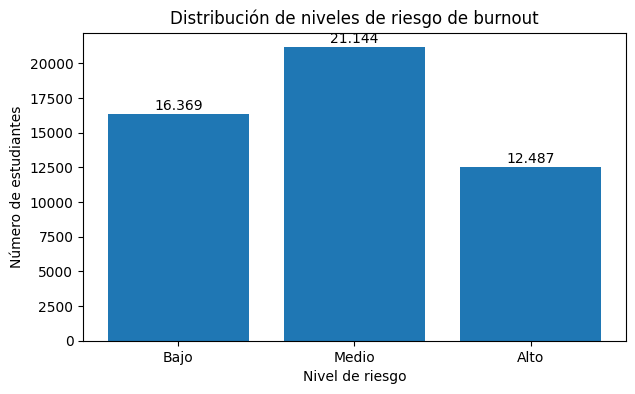

In [10]:
# Visualización de la distribución del riesgo de burnout
order = ['Low', 'Medium', 'High']
labels = ['Bajo', 'Medio', 'Alto']
counts = df['Burnout_Risk_Level'].value_counts().reindex(order)

plt.figure(figsize=(7, 4))
plt.bar(labels, counts.values)
plt.title('Distribución de niveles de riesgo de burnout')
plt.xlabel('Nivel de riesgo')
plt.ylabel('Número de estudiantes')
for i, v in enumerate(counts.values):
    plt.text(i, v + 300, f'{v:,}'.replace(',', '.'), ha='center')
plt.show()

## 8. Revisión de valores atípicos

Se utiliza el método IQR para identificar posibles valores atípicos. En esta etapa no se eliminan automáticamente, porque un valor extremo puede representar un caso válido e importante para el análisis.

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Student_ID')
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, lower, upper, outliers, outliers / len(df) * 100])

outlier_df = pd.DataFrame(outlier_summary, columns=['Variable', 'Límite inferior', 'Límite superior', 'Posibles atípicos', '%'])
outlier_df.round(3)

,Variable,Límite inferior,Límite superior,Posibles atípicos,%
0,Pre_Semester_GPA,1.804,4.552,328,0.656
1,Weekly_GenAI_Hours,-11.605,25.715,2583,5.166
2,Tool_Diversity,-1.000,7.000,0,0.000
3,Traditional_Study_Hours,-3.165,25.435,161,0.322
4,Perceived_AI_Dependency,-2.500,9.500,190,0.380
5,Anxiety_Level_During_Exams,-1.500,10.500,0,0.000
6,Post_Semester_GPA,1.936,4.837,346,0.692
7,Skill_Retention_Score,39.265,112.745,216,0.432


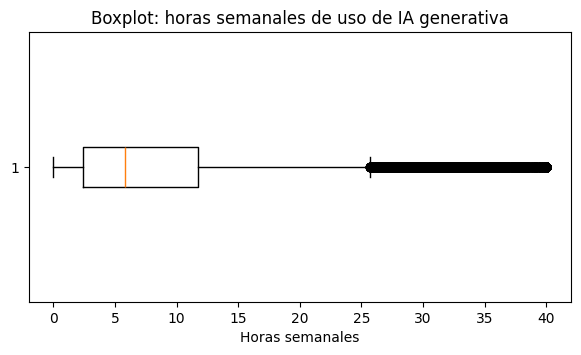

In [12]:
# Boxplot de la variable central de uso de IA
plt.figure(figsize=(7, 3.5))
plt.boxplot(df['Weekly_GenAI_Hours'], vert=False)
plt.title('Boxplot: horas semanales de uso de IA generativa')
plt.xlabel('Horas semanales')
plt.show()

## 9. Análisis univariado

Se revisan distribuciones de variables clave del proyecto.

In [13]:
key_numeric = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Perceived_AI_Dependency',
               'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']

summary_key = df[key_numeric].agg(['mean', 'median', 'std', 'min', 'max']).T
summary_key.round(3)

,mean,median,std,min,max
Weekly_GenAI_Hours,8.428,5.800,8.269,0.000,40.000
Traditional_Study_Hours,11.209,11.180,5.156,1.000,35.860
Perceived_AI_Dependency,3.505,3.000,1.821,1.000,10.000
Anxiety_Level_During_Exams,4.271,4.000,2.144,1.000,10.000
Post_Semester_GPA,3.349,3.421,0.496,1.000,4.000
Skill_Retention_Score,75.798,76.000,13.282,10.780,100.000


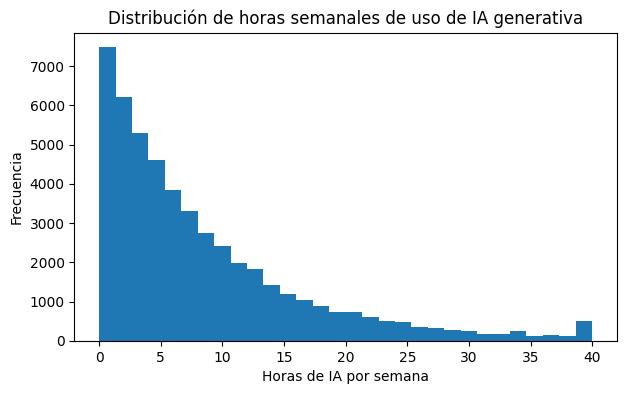

In [14]:
# Distribución de horas semanales de IA
plt.figure(figsize=(7, 4))
plt.hist(df['Weekly_GenAI_Hours'], bins=30)
plt.title('Distribución de horas semanales de uso de IA generativa')
plt.xlabel('Horas de IA por semana')
plt.ylabel('Frecuencia')
plt.show()

In [15]:
# Frecuencias de categorías principales
for col in ['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy']:
    print('\n', col)
    print(df[col].value_counts())


 Major_Category
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64

 Year_of_Study
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64

 Primary_Use_Case
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64

 Prompt_Engineering_Skill
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64

 Institutional_Policy
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


## 10. Análisis bivariado y relaciones clave

In [16]:
# Correlaciones entre variables numéricas clave
corr_cols = ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Traditional_Study_Hours',
             'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
             'Post_Semester_GPA', 'Skill_Retention_Score']

corr = df[corr_cols].corr().round(3)
corr

,Pre_Semester_GPA,Weekly_GenAI_Hours,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
Pre_Semester_GPA,1.000,-0.001,-0.005,0.001,-0.001,0.927,0.099
Weekly_GenAI_Hours,-0.001,1.000,-0.157,0.665,0.269,-0.019,-0.118
Traditional_Study_Hours,-0.005,-0.157,1.000,-0.103,-0.041,0.138,0.148
Perceived_AI_Dependency,0.001,0.665,-0.103,1.000,0.308,-0.014,-0.084
Anxiety_Level_During_Exams,-0.001,0.269,-0.041,0.308,1.000,-0.016,-0.042
Post_Semester_GPA,0.927,-0.019,0.138,-0.014,-0.016,1.000,0.170
Skill_Retention_Score,0.099,-0.118,0.148,-0.084,-0.042,0.170,1.000


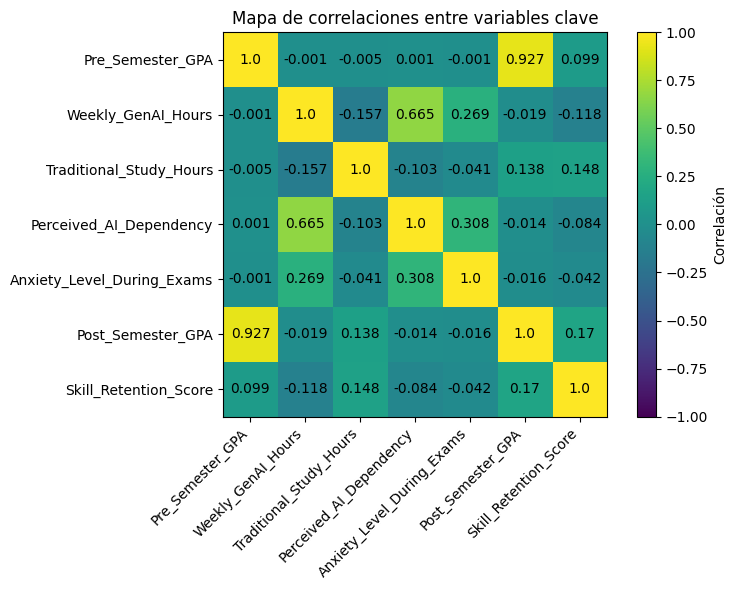

In [17]:
# Mapa de calor simple de correlaciones
plt.figure(figsize=(8, 6))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Mapa de correlaciones entre variables clave')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, corr.iloc[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

In [18]:
# Promedios de variables clave por nivel de riesgo de burnout
group_means = df.groupby('Burnout_Risk_Level')[[
    'Weekly_GenAI_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
    'Traditional_Study_Hours', 'Post_Semester_GPA', 'Skill_Retention_Score'
]].mean().reindex(['Low', 'Medium', 'High']).round(2)

group_means

,Weekly_GenAI_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Traditional_Study_Hours,Post_Semester_GPA,Skill_Retention_Score
Burnout_Risk_Level,,,,,,
Low,4.640,2.820,3.930,11.970,3.400,76.400
Medium,7.350,3.360,4.170,11.290,3.350,76.240
High,15.210,4.640,4.890,10.080,3.280,74.250


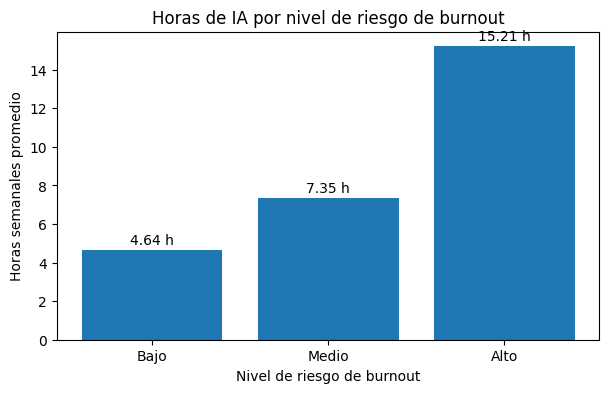

In [19]:
# Relación: horas de IA promedio por nivel de burnout
plt.figure(figsize=(7, 4))
plt.bar(['Bajo', 'Medio', 'Alto'], group_means['Weekly_GenAI_Hours'])
plt.title('Horas de IA por nivel de riesgo de burnout')
plt.xlabel('Nivel de riesgo de burnout')
plt.ylabel('Horas semanales promedio')
for i, v in enumerate(group_means['Weekly_GenAI_Hours']):
    plt.text(i, v + 0.3, f'{v:.2f} h', ha='center')
plt.show()

## 11. Hallazgo interesante

El grupo clasificado como `High` en `Burnout_Risk_Level` presenta, en promedio:

- más horas semanales de uso de IA generativa;
- mayor dependencia percibida de IA;
- mayor ansiedad durante exámenes;
- menos horas de estudio tradicional;
- menor retención promedio de habilidades;
- GPA final ligeramente menor.

Este hallazgo es relevante porque conecta directamente con el objetivo de negocio: identificar patrones de uso de IA y hábitos académicos asociados con niveles elevados de riesgo de burnout.

In [20]:
# Comparación resumida Low vs High
comparison = group_means.loc[['Low', 'High']].T
comparison['Diferencia High - Low'] = comparison['High'] - comparison['Low']
comparison.round(2)

Burnout_Risk_Level,Low,High,Diferencia High - Low
Weekly_GenAI_Hours,4.640,15.210,10.570
Perceived_AI_Dependency,2.820,4.640,1.820
Anxiety_Level_During_Exams,3.930,4.890,0.960
Traditional_Study_Hours,11.970,10.080,-1.890
Post_Semester_GPA,3.400,3.280,-0.120
Skill_Retention_Score,76.400,74.250,-2.150


## 12. Conclusiones de la fase de Entendimiento de los Datos

1. El dataset seleccionado tiene **50.000 registros y 16 variables**, con una unidad de análisis clara: el estudiante.
2. No se encontraron valores faltantes ni registros duplicados completos.
3. La variable objetivo principal será `Burnout_Risk_Level`, que representa **riesgo de burnout** en categorías Low, Medium y High.
4. El KPI principal es el **porcentaje de estudiantes clasificados con riesgo alto de burnout**, con línea base de **24,97%**.
5. Las variables más importantes para explicar el fenómeno son `Weekly_GenAI_Hours`, `Perceived_AI_Dependency`, `Anxiety_Level_During_Exams`, `Traditional_Study_Hours` y `Skill_Retention_Score`.
6. Se observó una relación relevante entre horas de uso de IA y dependencia percibida, con correlación aproximada de **0,665**.
7. Los resultados deben interpretarse como asociaciones del dataset, no como causalidad.

## Próxima fase: Preparación de los Datos

En la siguiente fase se deberá:

- excluir `Student_ID` como predictor;
- codificar variables categóricas;
- revisar valores atípicos;
- crear la variable `GPA_Change`;
- separar datasets para clasificación, regresión y clustering;
- prevenir fuga de información o data leakage.